<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/WeeklyModules/Week11/Participation_Activity_Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#Connect to my GitHub repository using the file distributed in class
%run '/content/drive/MyDrive/Google_connection.py'

Changed directory to: /content/MSSP6070/MSSP6070


<Figure size 640x480 with 0 Axes>

## Load Geospatial Data


In [14]:
import geopandas as gpd

districts_gdf = gpd.read_file('/content/MSSP6070/data/california-congressional-districts.geojson')
districts_gdf.head()

,Name,description,descriptio,geometry
0,01,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010..."
1,02,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967..."
2,03,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ..."
3,04,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823..."
4,05,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659..."


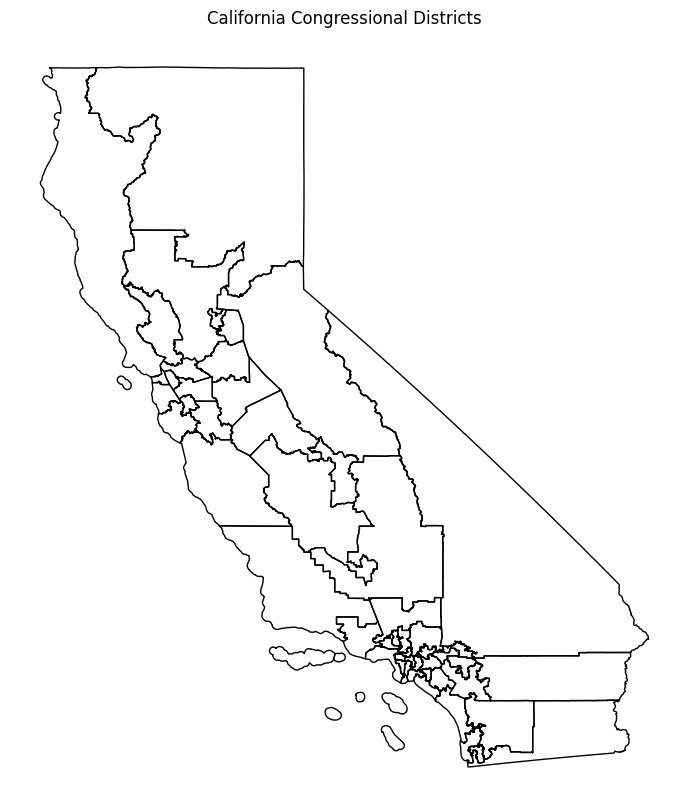

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
districts_gdf.plot(ax=ax, edgecolor='black', facecolor='none')
ax.set_title('California Congressional Districts')
ax.set_axis_off()
plt.show()

## Load Population Data



In [16]:
import pandas as pd

population_df = pd.read_csv('/content/MSSP6070/data/CA_Legislative_Districts.csv')
population_df.head()

,OBJECTID,ID,AREA,DISTRICT,MEMBERS,NAME,POPULATION,CVAP_19,HSP_CVAP_1,DOJ_NH_BLK,...,MULTIPLE_F,F_CVAP_19,F_HSP_CVAP,F_DOJ_NH_B,F_DOJ_NH_A,F_NH_WHT_C,DISTRICT_L,DISTRICT_N,SHAPE_Length,SHAPE_Area
0,1,1,27014.63,1,1,MTCAP,760066,549203,77031,10923,...,1|0,0.7226,0.1403,0.0199,0.0475,0.7507,1|0%,1,2.633906e+06,1.222952e+11
1,2,2,560.65,10,1,STANI,760066,503249,67160,26317,...,10|0,0.6621,0.1335,0.0523,0.1713,0.6220,10|0%,10,3.582890e+05,2.336909e+09
2,3,3,226.43,11,1,COCO,760067,568460,61171,33907,...,11|1,0.7479,0.1076,0.0596,0.3160,0.5006,11|0%,11,2.111932e+05,9.404054e+08
3,4,4,141.25,12,1,SF,760065,510978,74038,101894,...,12|-1,0.6723,0.1449,0.1994,0.2139,0.4169,12|-0%,12,1.246786e+05,5.869476e+08
4,5,5,6346.92,13,1,OKLND,760065,393416,197645,16042,...,13|-1,0.5176,0.5024,0.0408,0.0621,0.3708,13|-0%,13,1.186868e+06,2.578115e+10


## Prepare Data for Visualization



In [17]:
districts_gdf['Name'] = districts_gdf['Name'].astype(int)
print("Converted 'Name' column in districts_gdf to integer type.")

Converted 'Name' column in districts_gdf to integer type.


In [18]:
merged_gdf = districts_gdf.merge(population_df, left_on='Name', right_on='DISTRICT', how='left')
merged_gdf.head()

,Name,description,descriptio,geometry,OBJECTID,ID,AREA,DISTRICT,MEMBERS,NAME,...,MULTIPLE_F,F_CVAP_19,F_HSP_CVAP,F_DOJ_NH_B,F_DOJ_NH_A,F_NH_WHT_C,DISTRICT_L,DISTRICT_N,SHAPE_Length,SHAPE_Area
0,1,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010...",1.0,1.0,27014.63,1.0,1.0,MTCAP,...,1|0,0.7226,0.1403,0.0199,0.0475,0.7507,1|0%,1.0,2.633906e+06,1.222952e+11
1,2,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967...",12.0,12.0,14613.65,2.0,1.0,NOCST,...,2|1,0.7326,0.1095,0.0177,0.0426,0.7912,2|0%,2.0,2.160288e+06,6.486752e+10
2,3,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ...",23.0,23.0,22035.87,3.0,1.0,YUBA,...,3|-1,0.7229,0.1015,0.0153,0.0587,0.7984,3|-0%,3.0,2.954865e+06,9.186026e+10
3,4,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823...",34.0,34.0,3923.91,4.0,1.0,FTHLL,...,4|-1,0.6972,0.1995,0.0325,0.0785,0.6656,4|-0%,4.0,1.090719e+06,1.673268e+10
4,5,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659...",45.0,45.0,9962.22,5.0,1.0,NEBAY,...,5|-1,0.7192,0.1814,0.0229,0.0565,0.7132,5|-0%,5.0,1.771074e+06,4.132481e+10


## Visualize Congressional Districts with Population Overlay



In [19]:
!pip install contextily

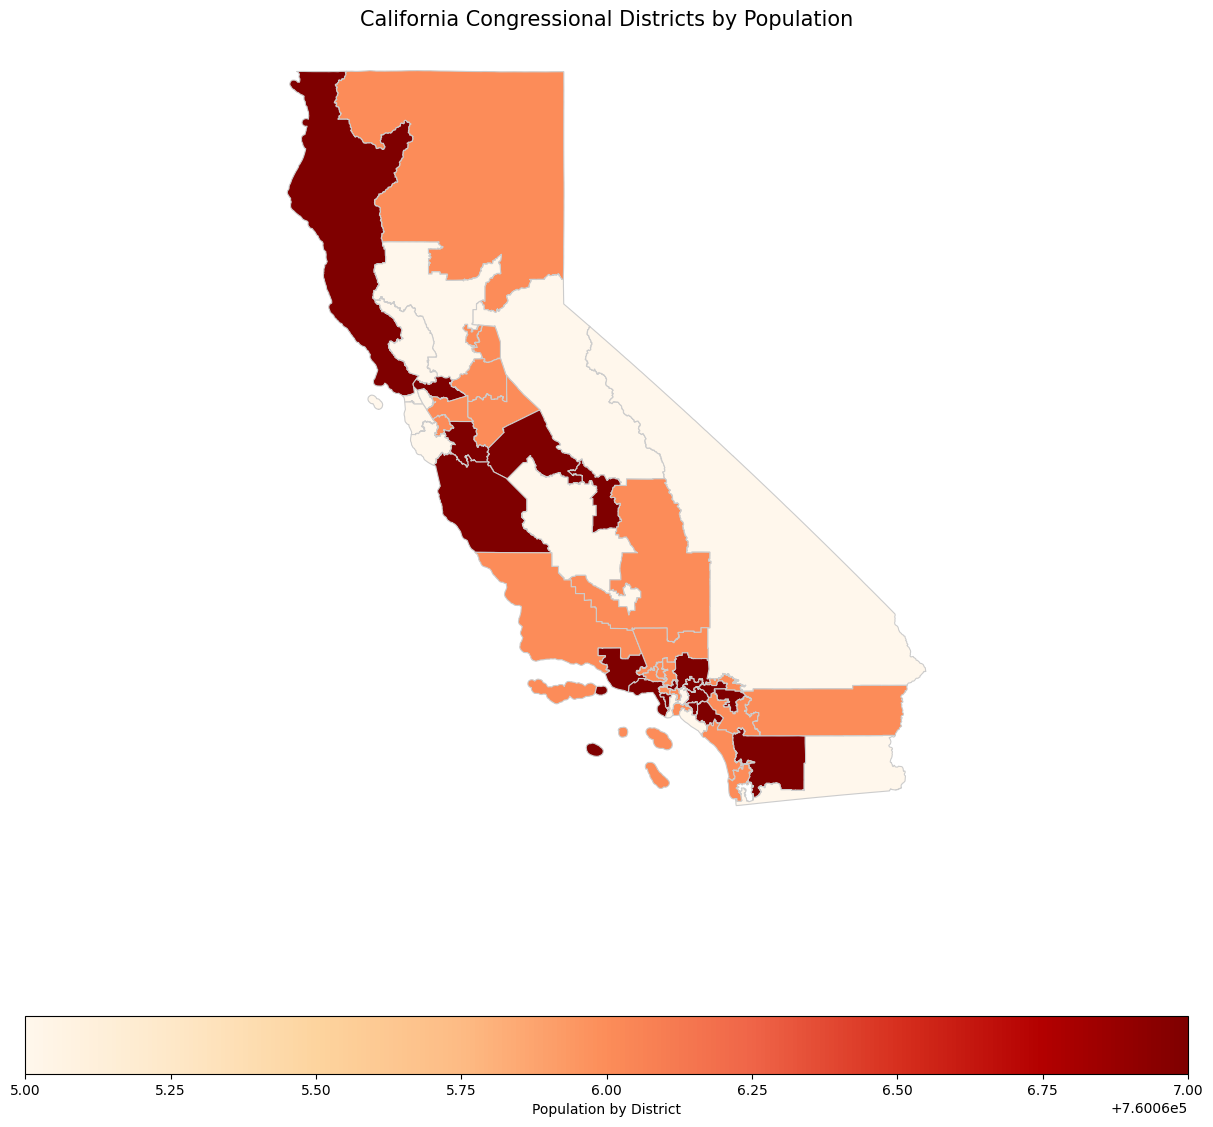

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
merged_gdf.plot(column='POPULATION', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                legend_kwds={'label': "Population by District", 'orientation': "horizontal"})
ax.set_title('California Congressional Districts by Population', fontsize=15)
ax.set_axis_off()
plt.show()

## Generate Population Heatmap


In [21]:
# calculate the population density for each congressional district
# store it in a new column named 'POPULATION_DENSITY'
merged_gdf['POPULATION_DENSITY'] = merged_gdf['POPULATION'] / merged_gdf['AREA']
print("Calculated 'POPULATION_DENSITY' for each district.")

Calculated 'POPULATION_DENSITY' for each district.


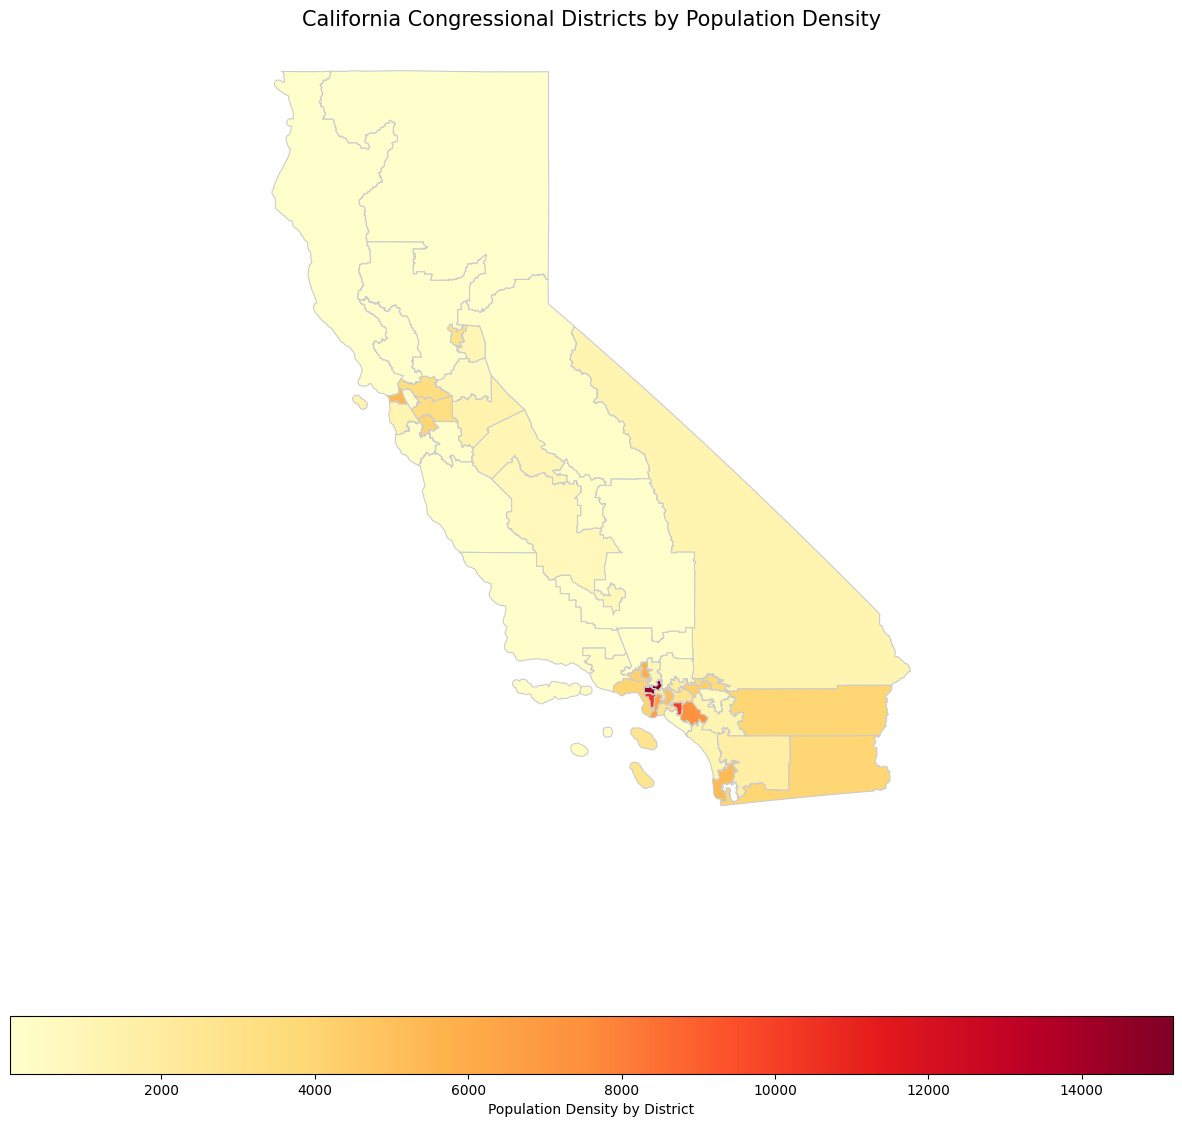

In [22]:
# update the existing visualizations to include a basemap for better geographical contex
# involve importing contextily and adding cx.add_basemap(ax) to each plot

fig, ax = plt.subplots(1, 1, figsize=(15, 15))
merged_gdf.plot(column='POPULATION_DENSITY', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True,
                legend_kwds={'label': "Population Density by District", 'orientation': "horizontal"})
ax.set_title('California Congressional Districts by Population Density', fontsize=15);
ax.set_axis_off();
plt.show()